In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/data_1.xlsx").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\data_1.xlsx


In [3]:
df = pd.read_excel(CSV_PATH)
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,...,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,0,0.094802,-0.325573,0.325573,0.094802,0.562500,0.906250,1.156250,15.353938,9.681293,2.665274,-2.477203,2.679014,-2.565224,5.117187,-0.922902,3.214947,1.219066,643.620154,23.794682,23.689110,23.689110,14.595754,14.249005,14.249005,15.671216,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,0,0.038844,-0.293526,0.293526,0.038844,0.620690,1.000000,1.310345,14.821216,9.700497,2.600529,-2.342885,2.644709,-2.322030,5.944502,0.193510,3.179270,1.120513,626.651366,20.916003,20.241516,20.241516,13.627794,12.704226,12.704226,12.411631,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,0,0.062897,-0.257239,0.257239,0.062897,0.600000,0.971429,1.257143,14.831112,9.700386,2.602486,-2.342009,2.648473,-2.318893,5.963448,0.193687,3.337074,1.136678,1101.164252,24.639617,22.617677,22.617677,16.526773,13.868825,13.868825,13.613700,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Очистка и изучение данных

In [4]:
df.info(max_cols=214)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 214 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    Unnamed: 0                1001 non-null   int64  
 1    IC50, mM                  1001 non-null   float64
 2    CC50, mM                  1001 non-null   float64
 3    SI                        1001 non-null   float64
 4    MaxAbsEStateIndex         1001 non-null   float64
 5    MaxEStateIndex            1001 non-null   float64
 6    MinAbsEStateIndex         1001 non-null   float64
 7    MinEStateIndex            1001 non-null   float64
 8    qed                       1001 non-null   float64
 9    SPS                       1001 non-null   float64
 10   MolWt                     1001 non-null   float64
 11   HeavyAtomMolWt            1001 non-null   float64
 12   ExactMolWt                1001 non-null   float64
 13   NumValenceElectrons       1001 non-null   int6

In [5]:
cols_with_na =  df.columns[df.isna().any()]
df_na = df[cols_with_na]
df_na.describe()

,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,0.235749,-0.407436,0.415741,0.227534,23.196621,9.792567,2.472204,-2.347064,2.473116,-2.403494,6.295386,-0.069485
std,0.129429,0.075974,0.071951,0.119641,14.529014,0.461284,0.162113,0.168873,0.157111,0.177036,1.090991,0.249599
min,-0.016706,-0.744036,0.085007,0.002020,14.513946,0.931261,1.834460,-2.721859,1.932099,-2.785712,4.652069,-1.080944
25%,0.118380,-0.477880,0.361390,0.116849,16.366967,9.689124,2.379808,-2.476096,2.357123,-2.529164,5.771986,-0.156878
50%,0.250661,-0.393567,0.426056,0.250661,16.564091,9.715411,2.505815,-2.358527,2.485135,-2.396486,5.938573,-0.113820
75%,0.335693,-0.354484,0.477880,0.330890,32.092047,9.980762,2.591035,-2.235685,2.612531,-2.323522,6.461007,0.059812
max,0.572596,-0.085007,0.744036,0.507387,126.912704,10.708899,2.822293,-1.713605,2.791427,-1.647760,14.111964,1.170324


In [6]:
df.info(max_cols=214)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 214 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    Unnamed: 0                1001 non-null   int64  
 1    IC50, mM                  1001 non-null   float64
 2    CC50, mM                  1001 non-null   float64
 3    SI                        1001 non-null   float64
 4    MaxAbsEStateIndex         1001 non-null   float64
 5    MaxEStateIndex            1001 non-null   float64
 6    MinAbsEStateIndex         1001 non-null   float64
 7    MinEStateIndex            1001 non-null   float64
 8    qed                       1001 non-null   float64
 9    SPS                       1001 non-null   float64
 10   MolWt                     1001 non-null   float64
 11   HeavyAtomMolWt            1001 non-null   float64
 12   ExactMolWt                1001 non-null   float64
 13   NumValenceElectrons       1001 non-null   int6

In [7]:
df = df.drop(columns=['Unnamed: 0'] if 'Unnamed: 0' in df.columns else [])
df = df.fillna(0.0)
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,...,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.648545,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,0,0.094802,-0.325573,0.325573,0.094802,0.562500,0.906250,1.156250,15.353938,9.681293,2.665274,-2.477203,2.679014,-2.565224,5.117187,-0.922902,3.214947,1.219066,643.620154,23.794682,23.689110,23.689110,14.595754,14.249005,14.249005,15.671216,15.671216,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,0,0.038844,-0.293526,0.293526,0.038844,0.620690,1.000000,1.310345,14.821216,9.700497,2.600529,-2.342885,2.644709,-2.322030,5.944502,0.193510,3.179270,1.120513,626.651366,20.916003,20.241516,20.241516,13.627794,12.704226,12.704226,12.411631,12.411631,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,0,0.062897,-0.257239,0.257239,0.062897,0.600000,0.971429,1.257143,14.831112,9.700386,2.602486,-2.342009,2.648473,-2.318893,5.963448,0.193687,3.337074,1.136678,1101.164252,24.639617,22.617677,22.617677,16.526773,13.868825,13.868825,13.613700,13.613700,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


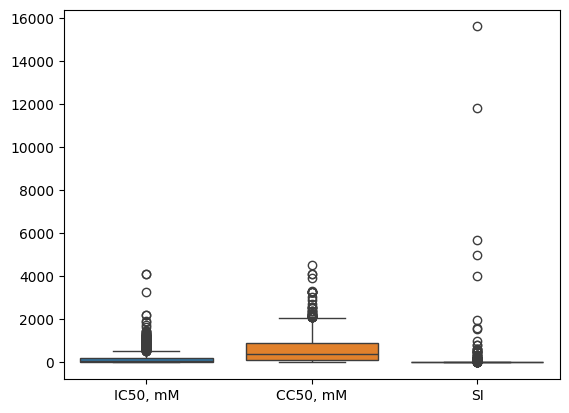

In [8]:
sns.boxplot(data = df[['IC50, mM', 'CC50, mM', 'SI']])
plt.show()

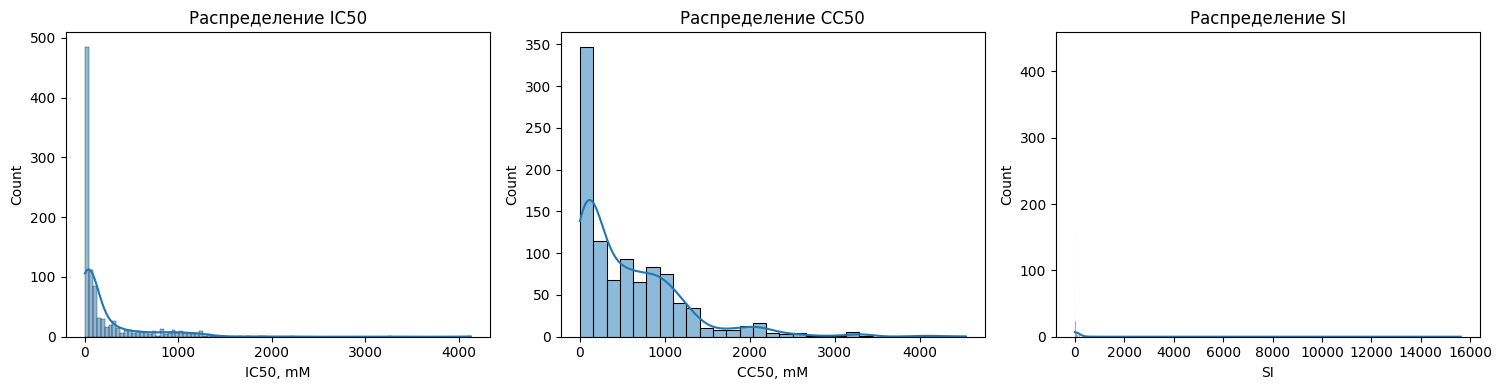

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['IC50, mM'], ax=axes[0], kde=True)
axes[0].set_title('Распределение IC50')
sns.histplot(df['CC50, mM'], ax=axes[1], kde=True)
axes[1].set_title('Распределение CC50')
sns.histplot(df['SI'], ax=axes[2], kde=True)
axes[2].set_title('Распределение SI')
plt.tight_layout()
plt.show()

<Axes: >

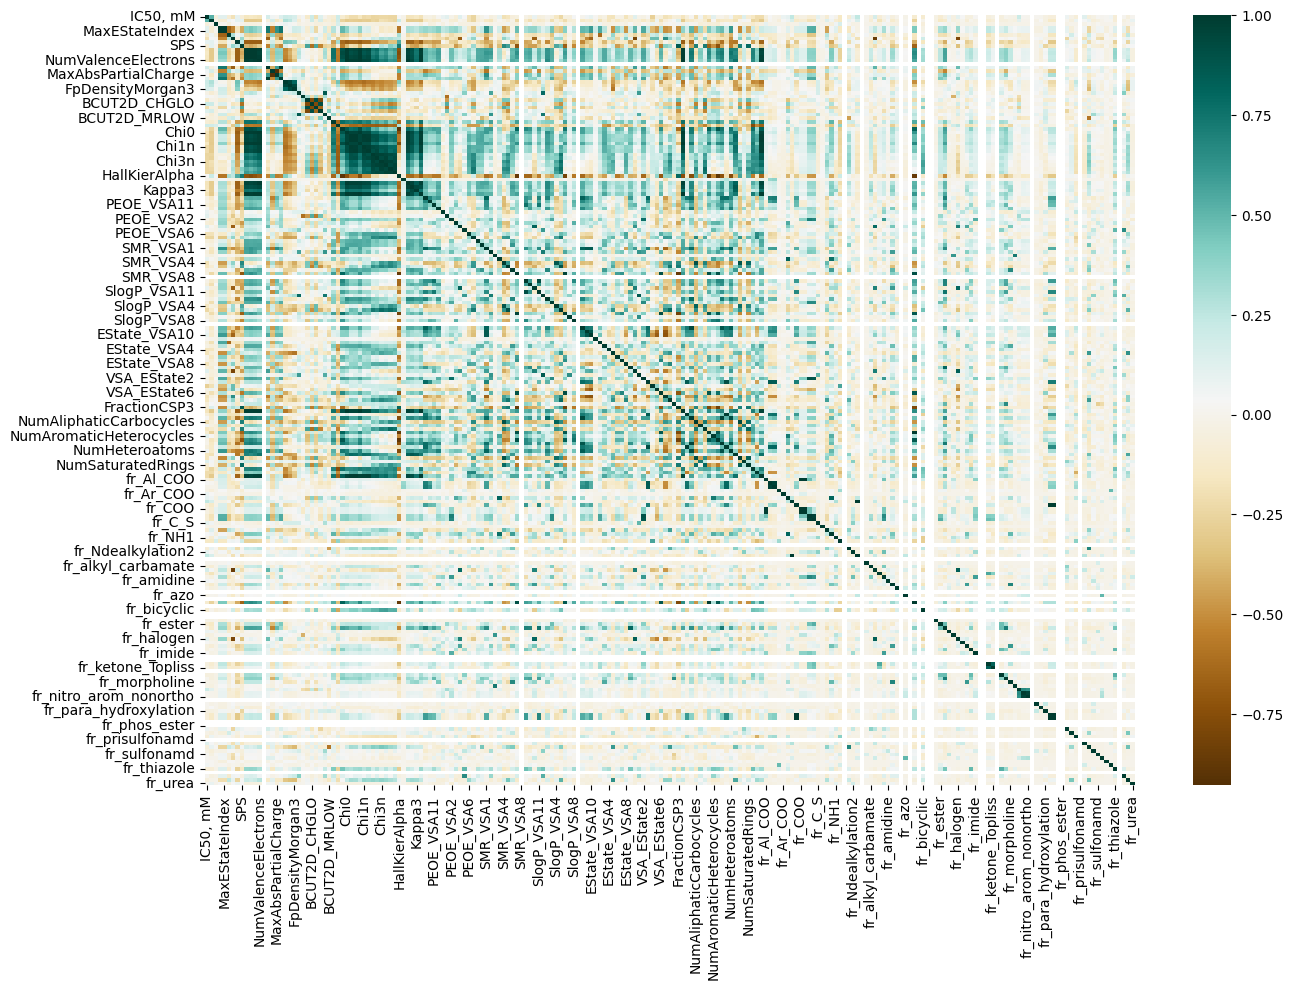

In [10]:
df_corr = df.corr()
f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df_corr, mask=np.zeros_like(df_corr, dtype=np.bool), cmap = "BrBG",ax=ax)


## Отбор признаков

Исключить сильно коррелированные признаки на основе корреляции с целевой переменной

In [11]:
def drop_multy_colmns(df, target, threshoid = 0.9):
    new_df = df.copy()
    df_corr = new_df.corr().abs()
    target_corr = new_df.corr()[target].abs()
    col_to_drop = set()
    upper = df_corr.where(np.triu(np.ones(df_corr.shape), k = 1).astype(bool))
    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > threshoid:
                if target_corr[row] >= target_corr[col]:
                    col_to_drop.add(col)
                else:
                    col_to_drop.add(row)
    return list(col_to_drop)

In [12]:
print(drop_multy_colmns(df, 'SI'))

['fr_COO', 'HeavyAtomMolWt', 'NumAliphaticCarbocycles', 'Chi1v', 'fr_COO2', 'fr_C_O_noCOO', 'NOCount', 'HeavyAtomCount', 'MolWt', 'SlogP_VSA6', 'ExactMolWt', 'LabuteASA', 'fr_phenol_noOrthoHbond', 'NumHDonors', 'Chi2v', 'fr_nitro_arom_nonortho', 'MolMR', 'Chi0v', 'BCUT2D_CHGLO', 'FpDensityMorgan3', 'MaxEStateIndex', 'Chi3n', 'MaxAbsPartialCharge', 'Chi0n', 'Chi2n', 'NumHeteroatoms', 'Kappa1', 'Chi4n', 'fr_Al_OH_noTert', 'FpDensityMorgan2', 'Chi3v', 'SMR_VSA7', 'HallKierAlpha', 'Kappa2', 'VSA_EState3', 'fr_Nhpyrrole', 'Chi1', 'Chi0', 'VSA_EState2', 'fr_benzene', 'SlogP_VSA11', 'fr_phenol', 'NumValenceElectrons', 'BCUT2D_CHGHI', 'Chi1n', 'MaxPartialCharge']


In [13]:
drop_list_si = drop_multy_colmns(df, 'SI')
drop_list_ic50 = drop_multy_colmns(df, 'IC50, mM')
drop_list_cc50 = drop_multy_colmns(df, 'CC50, mM')
print(f"Признаков для исключения IC50: {len(drop_list_ic50)}")
print(f"Признаков для исключения CC50: {len(drop_list_cc50)}")
print(f"Признаков для исключения SI: {len(drop_list_si)}")

Признаков для исключения IC50: 49
Признаков для исключения CC50: 48
Признаков для исключения SI: 46


Найти признаки с правой асимметрией

In [14]:
def skew_right(df, threshold = 0.5):
    skewness = df.skew(numeric_only = True)
    return skewness[skewness > threshold].index.tolist()

Найти признаки с левой асимметрией

In [15]:
def skew_left(df, threshold = 0.5):
    skewness = df.skew(numeric_only = True)
    return skewness[skewness < -threshold].index.tolist()

In [16]:
df_ic50_clean = df.drop(columns=drop_list_ic50)
X_ic50 = df_ic50_clean.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])

skew_right_ic50_list = skew_right(X_ic50, 0.5)
skew_left_ic50_list = skew_left(X_ic50, 0.5)

print(f"Признаков для исключения IC50: {len(drop_list_ic50)}")
print(f"Асимметричные признаки (правые) IC50: {len(skew_right_ic50_list)}")
print(f"Асимметричные признаки (левые) IC50: {len(skew_left_ic50_list)}")


Признаков для исключения IC50: 49
Асимметричные признаки (правые) IC50: 128
Асимметричные признаки (левые) IC50: 8


In [17]:
y_ic50 = df_ic50_clean['IC50, mM']
X_train, X_test, y_train, y_test = train_test_split(
    X_ic50, y_ic50, test_size=0.2, random_state=42
)

print(f"Обучающий набор: {X_train.shape}")
print(f"Тестовый набор:  {X_test.shape}")

Обучающий набор: (800, 161)
Тестовый набор:  (201, 161)


## Трансформер для асимметричных признаков

In [18]:
class SelectiveSkewTransformer(BaseEstimator, TransformerMixin):
    """Трансформировать только заданные асимметричные столбцы. Обучается только на данных обучения."""
    
    def __init__(self, skew_cols_right, skew_cols_left):
        self.skew_cols_right = skew_cols_right
        self.skew_cols_left = skew_cols_left
        self.pt_right = None
        self.pt_left = None
        self.all_skew_cols = skew_cols_right + skew_cols_left
    
    def fit(self, X, y=None):
        """Обучить только на данных обучения"""
        if self.skew_cols_right:
            self.pt_right = PowerTransformer(method="yeo-johnson")
            self.pt_right.fit(X[self.skew_cols_right])
        if self.skew_cols_left:
            self.pt_left = PowerTransformer(method="yeo-johnson")
            self.pt_left.fit(X[self.skew_cols_left])
        return self
    
    def transform(self, X):
        """Применить трансформации, обученные на данных обучения"""
        X_copy = X.copy()
        if self.skew_cols_right and self.pt_right is not None:
            X_copy[self.skew_cols_right] = self.pt_right.transform(X[self.skew_cols_right])
        if self.skew_cols_left and self.pt_left is not None:
            X_copy[self.skew_cols_left] = self.pt_left.transform(X[self.skew_cols_left])
        return X_copy

# Построение модели регресии IC50

In [19]:
X_ic50 = df_ic50_clean.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y_ic50 = df_ic50_clean['IC50, mM']
X_train, X_test, y_train, y_test = train_test_split(X_ic50, y_ic50, test_size=0.1, random_state=42)
pipeline_ic50 = Pipeline([
    ('skew_transform', SelectiveSkewTransformer(skew_right_ic50_list, skew_left_ic50_list)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=100))
])
pipeline_ic50.fit(X_train, y_train)

y_pred_train = pipeline_ic50.predict(X_train)
y_pred_test = pipeline_ic50.predict(X_test)


train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\n=== Производительность модели IC50 ===")
print(f"Обучение R2: {train_r2:.4f}")
print(f"Тест R2:  {test_r2:.4f}")
print(f"Обучение MAE: {train_mae:.4f}")
print(f"Тест MAE:  {test_mae:.4f}")
print(f"\nПоказатель переобучения: {abs(train_r2 - test_r2):.4f}")



=== Производительность модели IC50 ===
Обучение R2: 0.4692
Тест R2:  0.3147
Обучение MAE: 182.7128
Тест MAE:  269.8973

Показатель переобучения: 0.1546


In [20]:
df_cc50 = df.copy()
df_cc50 = df_cc50.drop(columns=drop_list_cc50)

In [21]:
skew_right_cc50_list = skew_right(df_cc50, 0.5)
print(skew_right_cc50_list)
print(len(skew_right_cc50_list))

skew_left_cc50_list = skew_left(df_cc50, 0.5)
print(skew_left_cc50_list)
print(len(skew_left_cc50_list))

['IC50, mM', 'CC50, mM', 'SI', 'MinAbsEStateIndex', 'MinPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_CHGLO', 'BCUT2D_MRHI', 'BalabanJ', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA7', 'SlogP_VSA8', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState10', 'VSA_EState8', 'VSA_EState9', 'NHOHCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHeteroatoms', 'NumRotatableBo

In [22]:
skew_cc50_list = skew_right_cc50_list + skew_left_cc50_list
new_df_cc50 = df_cc50.drop(columns=skew_cc50_list)
# sns.pairplot(new_df_cc50)
new_df_cc50.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SPS                  1001 non-null   float64
 1   NumRadicalElectrons  1001 non-null   int64  
 2   MinAbsPartialCharge  1001 non-null   float64
 3   FpDensityMorgan1     1001 non-null   float64
 4   AvgIpc               1001 non-null   float64
 5   SMR_VSA8             1001 non-null   int64  
 6   SlogP_VSA9           1001 non-null   int64  
 7   VSA_EState4          1001 non-null   float64
 8   FractionCSP3         1001 non-null   float64
 9   MolLogP              1001 non-null   float64
 10  fr_N_O               1001 non-null   int64  
 11  fr_SH                1001 non-null   int64  
 12  fr_azide             1001 non-null   int64  
 13  fr_barbitur          1001 non-null   int64  
 14  fr_benzodiazepine    1001 non-null   int64  
 15  fr_diazo             1001 non-null   i

In [23]:
skew_right_cc50_df  = df[skew_right_cc50_list]
pt = PowerTransformer(method="yeo-johnson")
skew_right_cc50_df = pt.fit_transform(skew_right_cc50_df)
skew_right_cc50_df = pd.DataFrame(skew_right_cc50_df, columns=skew_right_cc50_list)
skew_right_cc50_df.info(max_cols=200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 132 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    IC50, mM                  1001 non-null   float64
 1    CC50, mM                  1001 non-null   float64
 2    SI                        1001 non-null   float64
 3    MinAbsEStateIndex         1001 non-null   float64
 4    MinPartialCharge          1001 non-null   float64
 5    BCUT2D_MWHI               1001 non-null   float64
 6    BCUT2D_CHGLO              1001 non-null   float64
 7    BCUT2D_MRHI               1001 non-null   float64
 8    BalabanJ                  1001 non-null   float64
 9    Ipc                       1001 non-null   float64
 10   PEOE_VSA1                 1001 non-null   float64
 11   PEOE_VSA10                1001 non-null   float64
 12   PEOE_VSA11                1001 non-null   float64
 13   PEOE_VSA12                1001 non-null   floa

In [24]:
skew_left_cc50_df = df[skew_left_cc50_list]
pt = PowerTransformer(method="yeo-johnson")
skew_left_cc50_df = pt.fit_transform(skew_left_cc50_df)
skew_left_cc50_df = pd.DataFrame(skew_left_cc50_df, columns=skew_left_cc50_list)
skew_left_cc50_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MaxAbsEStateIndex  1001 non-null   float64
 1   MinEStateIndex     1001 non-null   float64
 2   qed                1001 non-null   float64
 3   BCUT2D_MWLOW       1001 non-null   float64
 4   BCUT2D_LOGPHI      1001 non-null   float64
 5   BCUT2D_MRLOW       1001 non-null   float64
 6   VSA_EState5        1001 non-null   float64
 7   VSA_EState7        1001 non-null   float64
dtypes: float64(8)
memory usage: 62.7 KB


In [25]:
skew_df_cc50_done = pd.concat([skew_right_cc50_df, skew_left_cc50_df, new_df_cc50], axis=1)
skew_df_cc50_done.info(max_cols=287)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 165 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    IC50, mM                  1001 non-null   float64
 1    CC50, mM                  1001 non-null   float64
 2    SI                        1001 non-null   float64
 3    MinAbsEStateIndex         1001 non-null   float64
 4    MinPartialCharge          1001 non-null   float64
 5    BCUT2D_MWHI               1001 non-null   float64
 6    BCUT2D_CHGLO              1001 non-null   float64
 7    BCUT2D_MRHI               1001 non-null   float64
 8    BalabanJ                  1001 non-null   float64
 9    Ipc                       1001 non-null   float64
 10   PEOE_VSA1                 1001 non-null   float64
 11   PEOE_VSA10                1001 non-null   float64
 12   PEOE_VSA11                1001 non-null   float64
 13   PEOE_VSA12                1001 non-null   floa

In [26]:
X_cc50 = skew_df_cc50_done.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y_cc50 = skew_df_cc50_done['CC50, mM']
X_train, X_test, y_train, y_test = train_test_split(X_cc50, y_cc50, test_size=0.1, random_state=42)
pipeline = Pipeline([('scaler', StandardScaler()),
                      ('model', Ridge(alpha=100))])
pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

0.4494785268626055

In [27]:
df_si = df.copy()
df_si = df_si.drop(columns=drop_list_si)

In [28]:
skew_right_si_list = skew_right(df_si, 0.5)
print(skew_right_si_list)
print(len(skew_right_si_list))

['IC50, mM', 'CC50, mM', 'SI', 'MinAbsEStateIndex', 'MinPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BalabanJ', 'BertzCT', 'Chi4v', 'Ipc', 'Kappa3', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA7', 'SlogP_VSA8', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState10', 'VSA_EState6', 'VSA_EState8', 'VSA_EState9', 'NHOHCount', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumRotatableBon

In [29]:
skew_left_si_list = skew_left(df_si, 0.5)
print(skew_left_si_list)
print(len(skew_left_si_list))

['MaxAbsEStateIndex', 'MinEStateIndex', 'qed', 'BCUT2D_MWLOW', 'BCUT2D_LOGPHI', 'BCUT2D_MRLOW', 'VSA_EState5', 'VSA_EState7']
8


In [30]:
skew_si_list = skew_right_si_list + skew_left_si_list
new_df_si = df_si.drop(columns=skew_si_list)
# sns.pairplot(new_df_si)
new_df_si.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SPS                  1001 non-null   float64
 1   NumRadicalElectrons  1001 non-null   int64  
 2   MinAbsPartialCharge  1001 non-null   float64
 3   FpDensityMorgan1     1001 non-null   float64
 4   AvgIpc               1001 non-null   float64
 5   SMR_VSA8             1001 non-null   int64  
 6   SlogP_VSA9           1001 non-null   int64  
 7   VSA_EState4          1001 non-null   float64
 8   FractionCSP3         1001 non-null   float64
 9   MolLogP              1001 non-null   float64
 10  fr_N_O               1001 non-null   int64  
 11  fr_SH                1001 non-null   int64  
 12  fr_azide             1001 non-null   int64  
 13  fr_barbitur          1001 non-null   int64  
 14  fr_benzodiazepine    1001 non-null   int64  
 15  fr_diazo             1001 non-null   i

In [31]:
skew_right_si_df  = df[skew_right_si_list]
pt = PowerTransformer(method="yeo-johnson")
skew_right_si_df = pt.fit_transform(skew_right_si_df)
skew_right_si_df = pd.DataFrame(skew_right_si_df, columns=skew_right_si_list)
skew_right_si_df.info(max_cols=200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 134 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    IC50, mM                  1001 non-null   float64
 1    CC50, mM                  1001 non-null   float64
 2    SI                        1001 non-null   float64
 3    MinAbsEStateIndex         1001 non-null   float64
 4    MinPartialCharge          1001 non-null   float64
 5    BCUT2D_MWHI               1001 non-null   float64
 6    BCUT2D_LOGPLOW            1001 non-null   float64
 7    BCUT2D_MRHI               1001 non-null   float64
 8    BalabanJ                  1001 non-null   float64
 9    BertzCT                   1001 non-null   float64
 10   Chi4v                     1001 non-null   float64
 11   Ipc                       1001 non-null   float64
 12   Kappa3                    1001 non-null   float64
 13   PEOE_VSA1                 1001 non-null   floa

In [32]:
skew_left_si_df = df[skew_left_si_list]
pt = PowerTransformer(method="yeo-johnson")
skew_left_si_df = pt.fit_transform(skew_left_si_df)
skew_left_si_df = pd.DataFrame(skew_left_si_df, columns=skew_left_si_list)
skew_left_si_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MaxAbsEStateIndex  1001 non-null   float64
 1   MinEStateIndex     1001 non-null   float64
 2   qed                1001 non-null   float64
 3   BCUT2D_MWLOW       1001 non-null   float64
 4   BCUT2D_LOGPHI      1001 non-null   float64
 5   BCUT2D_MRLOW       1001 non-null   float64
 6   VSA_EState5        1001 non-null   float64
 7   VSA_EState7        1001 non-null   float64
dtypes: float64(8)
memory usage: 62.7 KB


In [33]:
skew_df_si_done = pd.concat([skew_right_si_df, skew_left_si_df, new_df_si], axis=1)
skew_df_si_done.info(max_cols=287)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 167 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    IC50, mM                  1001 non-null   float64
 1    CC50, mM                  1001 non-null   float64
 2    SI                        1001 non-null   float64
 3    MinAbsEStateIndex         1001 non-null   float64
 4    MinPartialCharge          1001 non-null   float64
 5    BCUT2D_MWHI               1001 non-null   float64
 6    BCUT2D_LOGPLOW            1001 non-null   float64
 7    BCUT2D_MRHI               1001 non-null   float64
 8    BalabanJ                  1001 non-null   float64
 9    BertzCT                   1001 non-null   float64
 10   Chi4v                     1001 non-null   float64
 11   Ipc                       1001 non-null   float64
 12   Kappa3                    1001 non-null   float64
 13   PEOE_VSA1                 1001 non-null   floa

In [34]:
X_si = skew_df_si_done.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y_si = skew_df_si_done['SI']
X_train, X_test, y_train, y_test = train_test_split(X_si, y_si, test_size=0.1, random_state=42)
pipeline = Pipeline([('scaler', StandardScaler()),
                      ('model', Ridge(alpha=1000))])
pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

0.09237508582665177

In [35]:
df_ic50_median = df_ic50_clean.copy()
df_ic50_median['median_threshold'] = (df_ic50_median['IC50, mM'] > df_ic50_median['IC50, mM'].median()).astype(int)

print(df_ic50_median['median_threshold'].value_counts())

median_threshold
0    501
1    500
Name: count, dtype: int64


In [36]:
skew_df_si_done.to_csv(PROJECT_ROOT / Path("./data/si.csv").resolve(), index=False)
# skew_df_ic50_done.to_csv(PROJECT_ROOT / Path("./data/ic50.csv").resolve(), index=False)
df_ic50_median.to_csv(PROJECT_ROOT / Path("./data/ic50_median_threshold.csv").resolve())
skew_df_cc50_done.to_csv(PROJECT_ROOT / Path("./data/cc50.csv").resolve(), index=False)